# Linear Algebra for ML — Matrices, Vectors, Eigenvalues, SVD, Least Squares

*Part of the ML Course Reference Series.*

## LA1: How is data represented as a matrix and what is a vector?

A **dataset** is a matrix **X** of shape (n_samples x n_features):
- Each **row** = one sample (observation)
- Each **column** = one feature

A **vector** is a 1-D array. Every ML prediction is a matrix operation:

    y_hat = X @ w + b

All preprocessing (scaling, PCA, encoding) is a matrix transformation under the hood.

In [51]:
import numpy as np

X = np.array([[1.2, 0.5, 3.1],
              [2.4, 1.1, 0.8],
              [0.3, 2.2, 1.5],
              [1.8, 0.9, 2.7]])
print('Data matrix X (4 samples x 3 features):')
print(X)
print(f'Shape: {X.shape}')

print(f'\nSample 0 (row vector): {X[0]}')
print(f'Feature 1 (column vector): {X[:, 1]}')

w = np.array([0.5, -0.3, 1.0])  # learned weights
b = 0.1
y_hat = X @ w + b
print(f'\nPredictions y = Xw + b: {y_hat.round(3)}')

Data matrix X (4 samples x 3 features):
[[1.2 0.5 3.1]
 [2.4 1.1 0.8]
 [0.3 2.2 1.5]
 [1.8 0.9 2.7]]
Shape: (4, 3)

Sample 0 (row vector): [1.2 0.5 3.1]
Feature 1 (column vector): [0.5 1.1 2.2 0.9]

Predictions y = Xw + b: [3.65 1.77 1.09 3.43]


## LA2: What is Euclidean space and distance?

**Euclidean space R^n** is the n-dimensional real-number space where each point is a vector of n coordinates. Distance between two points is the L2 norm of their difference:

    d(a, b) = ||a - b||_2 = sqrt(sum (a_i - b_i)^2)

This is the distance KNN uses. Scaling features to the same range is critical — otherwise features with larger absolute values dominate the distance calculation.

In [52]:
import numpy as np
import matplotlib.pyplot as plt

a = np.array([1.0, 2.0])
b = np.array([4.0, 6.0])

d_euclidean = np.linalg.norm(a - b)
d_manhattan = np.linalg.norm(a - b, 1)
print(f'a = {a},  b = {b}')
print(f'Euclidean distance: {d_euclidean:.4f}  (sqrt((4-1)^2 + (6-2)^2))')
print(f'Manhattan distance: {d_manhattan:.4f}  (|4-1| + |6-2|)')

# Why scaling matters for KNN
p1 = np.array([1.0,    1000.0])  # age=1, income=1000
p2 = np.array([1.0,    2000.0])  # age=1, income=2000
p3 = np.array([50.0,   1001.0])  # age=50, income=1001
print('\nWithout scaling:')
print(f'  d(p1, p2) = {np.linalg.norm(p1-p2):.1f}  (differ only in income)')
print(f'  d(p1, p3) = {np.linalg.norm(p1-p3):.1f}  (differ heavily in age)')
print('  KNN would say p1 and p3 are farther apart even though income difference is tiny')

from sklearn.preprocessing import StandardScaler
scaled = StandardScaler().fit_transform([p1, p2, p3])
print('\nAfter StandardScaler:')
print(f'  d(p1, p2) = {np.linalg.norm(scaled[0]-scaled[1]):.3f}')
print(f'  d(p1, p3) = {np.linalg.norm(scaled[0]-scaled[2]):.3f}')

a = [1. 2.],  b = [4. 6.]
Euclidean distance: 5.0000  (sqrt((4-1)^2 + (6-2)^2))
Manhattan distance: 7.0000  (|4-1| + |6-2|)

Without scaling:
  d(p1, p2) = 1000.0  (differ only in income)
  d(p1, p3) = 49.0  (differ heavily in age)
  KNN would say p1 and p3 are farther apart even though income difference is tiny

After StandardScaler:
  d(p1, p2) = 2.122
  d(p1, p3) = 2.121


## LA3: What is an orthonormal basis?

A set of vectors forms an **orthonormal basis** when:
1. **Orthogonal:** every pair of vectors is perpendicular (dot product = 0)
2. **Normal (unit length):** every vector has L2 norm = 1

Why it matters in ML:
- PCA principal components are an orthonormal basis of the feature space
- The U and V matrices in SVD are orthonormal
- Projecting onto an orthonormal basis is computationally cheap: just a dot product
- Projections are non-overlapping — each component captures unique variance

In [53]:
import numpy as np

# Standard basis of R^3 (canonical example)
e1 = np.array([1., 0., 0.])
e2 = np.array([0., 1., 0.])
e3 = np.array([0., 0., 1.])

print('Standard basis of R^3:')
for i, (u, v) in enumerate([(e1,e2),(e1,e3),(e2,e3)]):
    print(f'  e{i+1} dot e{i+2}: {np.dot(u,v):.1f}  (should be 0 = orthogonal)')
for i, e in enumerate([e1, e2, e3]):
    print(f'  ||e{i+1}|| = {np.linalg.norm(e):.1f}  (should be 1 = unit length)')

# PCA components are orthonormal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

X_iris, _ = load_iris(return_X_y=True)
X_sc = StandardScaler().fit_transform(X_iris)
pca = PCA(n_components=4).fit(X_sc)
V = pca.components_  # shape (4, 4) — each row is a principal component

print('\nPCA components are orthonormal:')
print('  V @ V.T (should be identity):')
print((V @ V.T).round(10))

# Projection: coordinates of data in PC space = just a matrix multiply
X_proj = X_sc @ V.T  # same as pca.transform(X_sc)
print(f'\nProjected data shape: {X_proj.shape}  (150 samples x 4 components)')
print(f'Variance per component: {pca.explained_variance_ratio_.round(3)}')

Standard basis of R^3:
  e1 dot e2: 0.0  (should be 0 = orthogonal)
  e2 dot e3: 0.0  (should be 0 = orthogonal)
  e3 dot e4: 0.0  (should be 0 = orthogonal)
  ||e1|| = 1.0  (should be 1 = unit length)
  ||e2|| = 1.0  (should be 1 = unit length)
  ||e3|| = 1.0  (should be 1 = unit length)

PCA components are orthonormal:
  V @ V.T (should be identity):
[[ 1. -0. -0. -0.]
 [-0.  1.  0.  0.]
 [-0.  0.  1.  0.]
 [-0.  0.  0.  1.]]

Projected data shape: (150, 4)  (150 samples x 4 components)
Variance per component: [0.73  0.229 0.037 0.005]


## LA4: What is matrix rank — and what does rank-K mean in SVD/PCA?

The **rank** of a matrix = number of linearly independent rows (or columns) = the true number of dimensions the data spans.

In SVD: `M = U S V^T` where S is diagonal with singular values s_1 >= s_2 >= ... >= s_r > 0.
The rank equals the number of **non-zero singular values**.

**Rank-K approximation** keeps only the K largest singular values:

    M_K = U[:, :K] @ diag(s[:K]) @ V^T[:K, :]

This is the *closest* rank-K matrix to M (Eckart-Young theorem). Each kept component captures the next most important direction of variation.

Full-rank matrix rank: 3
Rank-deficient matrix rank: 2 (3x3 but rank=2)
Singular values: [15.663323  0.812594  0.      ]  <- last one ~0 confirms rank=2

Rank-K approximation of a 30x15 matrix:
    K   Var explained   Frobenius error
    1          19.0%           19.2218
    3          45.2%           15.8121
    5          63.5%           12.9093
   10          90.7%            6.5057
   15         100.0%            0.0000


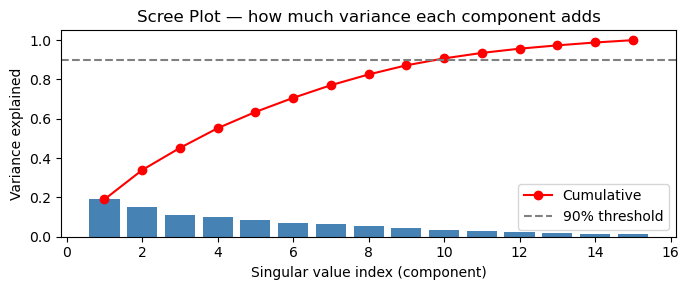

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Matrix rank
A_full = np.array([[1.,0.,0.],[0.,2.,0.],[0.,0.,3.]])
A_rank2 = np.array([[1.,2.,3.],[4.,5.,6.],[5.,7.,9.]])  # row3=row1+row2
print(f'Full-rank matrix rank: {np.linalg.matrix_rank(A_full)}')
print(f'Rank-deficient matrix rank: {np.linalg.matrix_rank(A_rank2)} (3x3 but rank=2)')

U, s, Vt = np.linalg.svd(A_rank2)
print(f'Singular values: {s.round(6)}  <- last one ~0 confirms rank=2')

# Rank-K approximation quality
rng = np.random.default_rng(0)
M = rng.normal(size=(30, 15))
U, s, Vt = np.linalg.svd(M, full_matrices=False)
total_var = (s**2).sum()

print(f'\nRank-K approximation of a 30x15 matrix:')
print(f'  {"K":>3}  {"Var explained":>14}  {"Frobenius error":>16}')
for k in [1, 3, 5, 10, 15]:
    M_k = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    var = (s[:k]**2).sum() / total_var
    err = np.linalg.norm(M - M_k, 'fro')
    print(f'  {k:>3}  {var:>13.1%}  {err:>16.4f}')

# Scree plot: variance explained by each singular value
var_explained = (s**2) / total_var
plt.figure(figsize=(7, 3))
plt.bar(range(1, len(s)+1), var_explained, color='steelblue')
plt.plot(range(1, len(s)+1), np.cumsum(var_explained), 'ro-', label='Cumulative')
plt.axhline(0.9, color='gray', linestyle='--', label='90% threshold')
plt.xlabel('Singular value index (component)')
plt.ylabel('Variance explained')
plt.title('Scree Plot — how much variance each component adds')
plt.legend()
plt.tight_layout()
plt.show()

## LA5: Key matrix operations — dot product, transpose, inverse, determinant

| Operation | Code | When used in ML |
|---|---|---|
| Dot product | `np.dot(a, b)` | Similarity; every linear model prediction |
| Matrix multiply | `A @ B` | Apply transformations; batch predictions |
| Transpose | `A.T` | OLS formula `(X^T X)^{-1} X^T y` |
| Inverse | `np.linalg.inv(A)` | OLS closed-form solution |
| Determinant | `np.linalg.det(A)` | Checks if matrix is invertible (det=0 -> singular) |

In [55]:
import numpy as np

a = np.array([1., 2., 3.])
b = np.array([4., 5., 6.])

# Dot product
print(f'a . b = {np.dot(a, b)}  (= 1*4 + 2*5 + 3*6)')
cos_theta = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
print(f'angle(a, b) = {np.degrees(np.arccos(cos_theta)):.2f} deg')

# Transpose
A = np.array([[1,2,3],[4,5,6]])
print(f'\nA shape {A.shape}  ->  A.T shape {A.T.shape}')

# Inverse
M = np.array([[2., 1.],[1., 3.]])
M_inv = np.linalg.inv(M)
print(f'\nM @ M_inv (identity check):')
print((M @ M_inv).round(10))

# Determinant
print(f'\ndet(M) = {np.linalg.det(M):.4f}  (non-zero -> invertible)')
singular = np.array([[1., 2.],[2., 4.]])  # linearly dependent rows
print(f'det(singular) = {np.linalg.det(singular):.4f}  -> not invertible')

# OLS closed form: w = (X^T X)^-1 X^T y
rng = np.random.default_rng(42)
X_d = rng.normal(size=(50, 2))
y_d = 3*X_d[:,0] - 2*X_d[:,1] + rng.normal(scale=0.1, size=50)
X_b = np.hstack([np.ones((50,1)), X_d])
w_ols = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_d
print(f'\nOLS w = (X^T X)^-1 X^T y:')
print(f'  intercept={w_ols[0]:.3f}, w1={w_ols[1]:.3f}, w2={w_ols[2]:.3f}')
print(f'  True: intercept=0, w1=3, w2=-2')

a . b = 32.0  (= 1*4 + 2*5 + 3*6)
angle(a, b) = 12.93 deg

A shape (2, 3)  ->  A.T shape (3, 2)

M @ M_inv (identity check):
[[ 1.  0.]
 [-0.  1.]]

det(M) = 5.0000  (non-zero -> invertible)
det(singular) = 0.0000  -> not invertible

OLS w = (X^T X)^-1 X^T y:
  intercept=-0.006, w1=3.010, w2=-2.017
  True: intercept=0, w1=3, w2=-2


## LA6: What are eigenvalues and eigenvectors — the foundation of PCA?

For a square matrix **A**, an **eigenvector** v is a special direction that A only *stretches*, never *rotates*:

    A v = lambda v

- **v** = eigenvector (direction preserved by the transformation)
- **lambda** = eigenvalue (stretch factor)

**PCA:** computes the covariance matrix of the (centred, scaled) data, then finds its eigenvectors. These are the principal components — directions of maximum variance. Larger eigenvalue = more important direction.

A: [[3. 1.]
 [1. 3.]]
Eigenvalues:  [4. 2.]
Eigenvectors (columns):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

A @ v0 = [2.828427 2.828427]
lv0 * v0 = [2.828427 2.828427]  <- same

A @ v1 = [-1.414214  1.414214]
lv1 * v1 = [-1.414214  1.414214]  <- same

Covariance eigenvalues: [5.89  0.219]
Variance explained: [0.964 0.036]


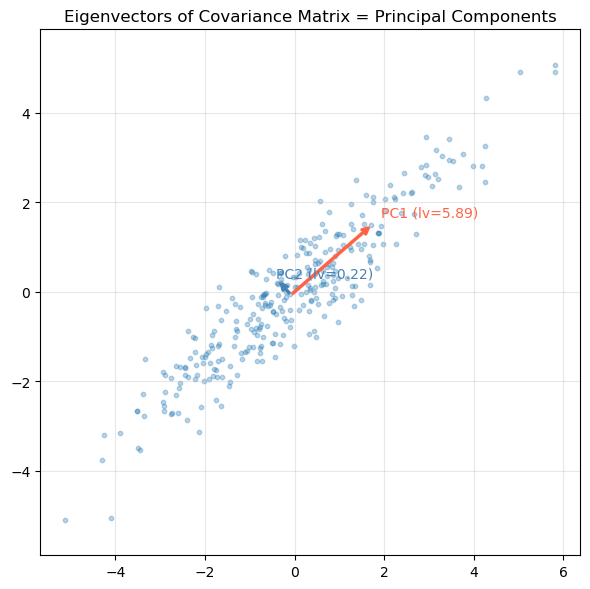

In [56]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[3., 1.],[1., 3.]])
eigenvalues, eigenvectors = np.linalg.eig(A)
print('A:', A)
print(f'Eigenvalues:  {eigenvalues}')
print(f'Eigenvectors (columns):\n{eigenvectors}')

for i in range(2):
    v = eigenvectors[:, i]
    lv = eigenvalues[i]
    print(f'\nA @ v{i} = {(A @ v).round(6)}')
    print(f'lv{i} * v{i} = {(lv * v).round(6)}  <- same')

# PCA via covariance matrix eigenvectors
rng = np.random.default_rng(42)
x1 = rng.normal(0, 2, 300)
x2 = 0.8*x1 + rng.normal(0, 0.6, 300)
X2d = np.column_stack([x1, x2])
cov = np.cov(X2d.T)
evals, evecs = np.linalg.eig(cov)
order = np.argsort(evals)[::-1]
evals, evecs = evals[order], evecs[:, order]
print(f'\nCovariance eigenvalues: {evals.round(3)}')
print(f'Variance explained: {(evals/evals.sum()).round(3)}')

plt.figure(figsize=(6, 6))
plt.scatter(X2d[:, 0], X2d[:, 1], alpha=0.3, s=10)
origin = X2d.mean(axis=0)
for i in range(2):
    vec = evecs[:, i]
    scale = np.sqrt(evals[i])
    plt.annotate('', xy=origin + scale*vec, xytext=origin,
                 arrowprops=dict(arrowstyle='->', color=['tomato','steelblue'][i], lw=2.5))
    plt.text(*(origin + scale*vec*1.1), f'PC{i+1} (lv={evals[i]:.2f})', fontsize=10,
             color=['tomato','steelblue'][i])
plt.axis('equal')
plt.title('Eigenvectors of Covariance Matrix = Principal Components')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## LA7: What are vector/matrix norms?

A **norm** measures the size of a vector or matrix.

| Norm | Formula | Name | Used for |
|---|---|---|---|
| L1 | sum |x_i| | Manhattan | Lasso penalty; sparse signals |
| L2 | sqrt(sum x_i^2) | Euclidean | KNN distance; Ridge penalty |
| L-inf | max |x_i| | Chebyshev | Worst-case error |
| Frobenius | sqrt(sum A_ij^2) | Matrix L2 | SVD approximation error |

L1 norms encourage **sparsity** (corners of the constraint ball lie on axes). L2 norms encourage **small but non-zero** weights.

v = [ 3. -4.  0.  1.]
L1 norm: 8.0000  = |3|+|-4|+|0|+|1|
L2 norm: 5.0990  = sqrt(9+16+0+1)
Linf norm: 4.0000  = max(3,4,0,1)
Frobenius norm: 5.4772  = sqrt(1+4+9+16)


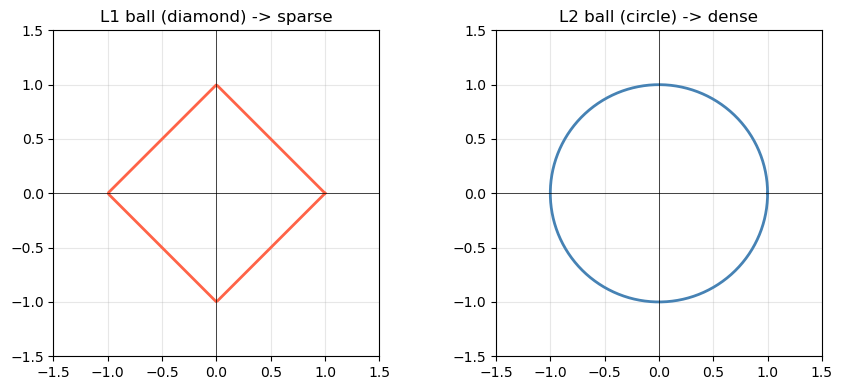

In [57]:
import numpy as np
import matplotlib.pyplot as plt

v = np.array([3., -4., 0., 1.])
print(f'v = {v}')
print(f'L1 norm: {np.linalg.norm(v, 1):.4f}  = |3|+|-4|+|0|+|1|')
print(f'L2 norm: {np.linalg.norm(v, 2):.4f}  = sqrt(9+16+0+1)')
print(f'Linf norm: {np.linalg.norm(v, np.inf):.4f}  = max(3,4,0,1)')

A = np.array([[1.,2.],[3.,4.]])
print(f'Frobenius norm: {np.linalg.norm(A, "fro"):.4f}  = sqrt(1+4+9+16)')

# L1 vs L2 unit balls in 2D
theta = np.linspace(0, 2*np.pi, 500)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, p, title, color in [
        (axes[0], 1, 'L1 ball (diamond) -> sparse', 'tomato'),
        (axes[1], 2, 'L2 ball (circle) -> dense',   'steelblue')]:
    pts = np.column_stack([np.cos(theta), np.sin(theta)])
    r = 1.0 / (np.sum(np.abs(pts)**p, axis=1)**(1/p) + 1e-12)
    pts_s = pts * r[:, None]
    ax.plot(pts_s[:, 0], pts_s[:, 1], color=color, linewidth=2)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## LA8: What is Least Squares and how is it derived?

**Goal:** find weights **w** that minimise the sum of squared errors between predictions and targets:

    Loss(w) = ||Xw - y||_2^2 = (Xw - y)^T (Xw - y)

**Derivation:** take the gradient, set to zero:

    dLoss/dw = 2 X^T (Xw - y) = 0
    X^T X w = X^T y
    w = (X^T X)^{-1} X^T y     <- Normal equations

This is the **OLS (Ordinary Least Squares)** solution — the unique global minimum when X has full column rank.

When X is nearly singular (collinear features), `(X^T X)^{-1}` becomes numerically unstable. Ridge regression adds `alpha * I` to fix this: `w = (X^T X + alpha I)^{-1} X^T y`.

OLS via normal equations:
  intercept = 0.8920  (true: 1.0)
  slope     = 2.0724  (true: 2.0)

sklearn LinearRegression: intercept=0.8920, slope=2.0724

Ridge (alpha=1) via closed form: intercept=0.8721, slope=2.0734


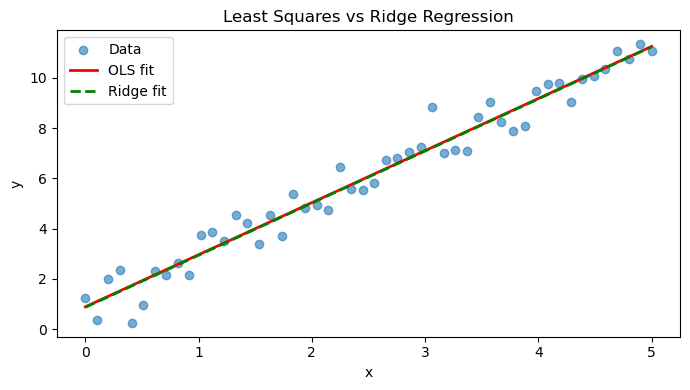

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data
rng = np.random.default_rng(42)
x = np.linspace(0, 5, 50)
y = 2.0 * x + 1.0 + rng.normal(scale=0.8, size=50)

# OLS via normal equations
X_b = np.column_stack([np.ones_like(x), x])  # add bias column
w_ols = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
print(f'OLS via normal equations:')
print(f'  intercept = {w_ols[0]:.4f}  (true: 1.0)')
print(f'  slope     = {w_ols[1]:.4f}  (true: 2.0)')

# Verify: same as sklearn
from sklearn.linear_model import LinearRegression, Ridge
lr_sk = LinearRegression().fit(x.reshape(-1,1), y)
print(f'\nsklearn LinearRegression: intercept={lr_sk.intercept_:.4f}, slope={lr_sk.coef_[0]:.4f}')

# Ridge = (X^T X + alpha I)^-1 X^T y
alpha = 1.0
n_feat = X_b.shape[1]
w_ridge = np.linalg.inv(X_b.T @ X_b + alpha * np.eye(n_feat)) @ X_b.T @ y
print(f'\nRidge (alpha=1) via closed form: intercept={w_ridge[0]:.4f}, slope={w_ridge[1]:.4f}')

# Plot fit
x_line = np.linspace(0, 5, 100)
plt.figure(figsize=(7, 4))
plt.scatter(x, y, alpha=0.6, label='Data')
plt.plot(x_line, w_ols[0] + w_ols[1]*x_line, 'r-', linewidth=2, label='OLS fit')
plt.plot(x_line, w_ridge[0] + w_ridge[1]*x_line, 'g--', linewidth=2, label='Ridge fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Least Squares vs Ridge Regression')
plt.legend()
plt.tight_layout()
plt.show()

## LA9: OLS vs Gradient Descent — when to use which?

Both solve the same linear regression problem, but differently:

| | OLS (Normal Equations) | Gradient Descent |
|---|---|---|
| **Method** | Exact closed-form solution | Iterative approximation |
| **Formula** | w = (XᵀX)⁻¹Xᵀy | w ← w − α∇Loss |
| **Speed (small data)** | Fast | Slower (many iterations) |
| **Speed (large data)** | Slow — O(p³) matrix inversion | Fast — O(n·p) per step |
| **Hyperparameters** | None | Learning rate α, n_iterations |
| **Numerical stability** | Fails if XᵀX is singular | Always applicable |
| **Generalises to** | Linear models only | Any differentiable loss (neural nets!) |

**Rule:** use OLS when n_features is small (< ~10k). Use gradient descent / SGD for large-scale problems.

n=   500, p=  5:  OLS    0.2ms MSE=0.2556 | SGD    2.5ms MSE=0.2556


n= 10000, p=100:  OLS  210.6ms MSE=0.2454 | SGD   46.8ms MSE=0.2504


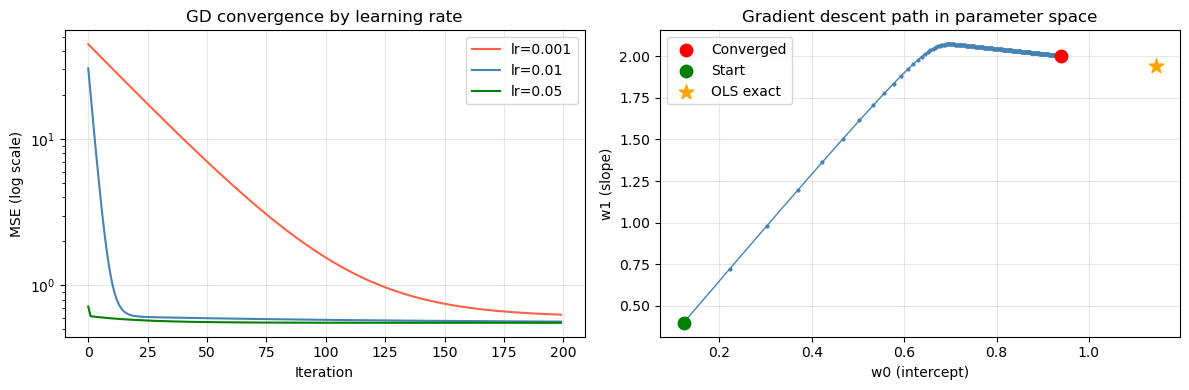

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

rng = np.random.default_rng(42)

for n, p in [(500, 5), (10_000, 100)]:
    X = rng.normal(size=(n, p))
    w_true = rng.normal(size=p)
    y = X @ w_true + rng.normal(scale=0.5, size=n)

    # OLS
    t0 = time.perf_counter()
    X_b = np.hstack([np.ones((n,1)), X])
    w_ols = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
    t_ols = time.perf_counter() - t0

    # SGD
    t0 = time.perf_counter()
    sgd = Pipeline([('scl', StandardScaler()),
                    ('sgd', SGDRegressor(max_iter=1000, random_state=42))])
    sgd.fit(X, y)
    t_sgd = time.perf_counter() - t0

    ols_err = np.mean((X @ w_ols[1:] + w_ols[0] - y)**2)
    sgd_err = np.mean((sgd.predict(X) - y)**2)

    print(f'n={n:6d}, p={p:3d}:  OLS {t_ols*1000:6.1f}ms MSE={ols_err:.4f} | '
          f'SGD {t_sgd*1000:6.1f}ms MSE={sgd_err:.4f}')

# ── Visualise gradient descent convergence ───────────────────────────────────
rng2 = np.random.default_rng(0)
x1d = rng2.uniform(0, 5, 80)
y1d = 2*x1d + 1 + rng2.normal(0, 0.8, 80)
X1d = np.column_stack([np.ones_like(x1d), x1d])

def gd_path(X, y, lr, n_iter=200):
    w = np.zeros(X.shape[1])
    losses, ws = [], []
    for _ in range(n_iter):
        grad = (2/len(y)) * X.T @ (X @ w - y)
        w = w - lr * grad
        losses.append(np.mean((X @ w - y)**2))
        ws.append(w.copy())
    return losses, ws

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
for lr, color in [(0.001,'tomato'),(0.01,'steelblue'),(0.05,'green')]:
    losses, _ = gd_path(X1d, y1d, lr)
    axes[0].plot(losses, color=color, label=f'lr={lr}')
axes[0].set_yscale('log')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE (log scale)')
axes[0].set_title('GD convergence by learning rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Weight trajectory (parameter space)
_, ws = gd_path(X1d, y1d, 0.01)
ws = np.array(ws)
axes[1].plot(ws[:, 0], ws[:, 1], 'o-', markersize=2, linewidth=1, color='steelblue')
axes[1].scatter([ws[-1,0]], [ws[-1,1]], color='red', s=80, zorder=5, label='Converged')
axes[1].scatter([ws[0,0]],  [ws[0,1]],  color='green', s=80, zorder=5, label='Start')
w_ols_1d = np.linalg.inv(X1d.T@X1d)@X1d.T@y1d
axes[1].scatter([w_ols_1d[0]], [w_ols_1d[1]], color='orange', s=120, zorder=5,
                marker='*', label=f'OLS exact')
axes[1].set_xlabel('w0 (intercept)')
axes[1].set_ylabel('w1 (slope)')
axes[1].set_title('Gradient descent path in parameter space')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Summary Table

| Topic | Key concept | Covered in |
|---|---|---|
| Train-test split | Honest evaluation | Q2 |
| Cross-validation | Stable score estimate | Q3 |
| Missing values | SimpleImputer | Q4 |
| Scaling | StandardScaler / MinMaxScaler | Q5 |
| Encoding | OneHotEncoder | Q6 |
| Pipeline | Prevent leakage | Q7, Q34 |
| ColumnTransformer | Mixed data types | Q8 |
| KNN | Distance-based voting | Q9 |
| Decision Tree | Recursive splitting | Q10 |
| Random Forest | Ensemble / bagging | Q11 |
| Logistic Regression | Sigmoid / linear boundary | Q12 |
| Naive Bayes | Bayes + independence | Q13 |
| SVM | Max-margin hyperplane | Q14 |
| Linear Regression (OLS) | Closed-form least squares | Q15 |
| Gradient Descent | Iterative optimisation | Q16 |
| Regularisation (L1/L2) | Ridge, Lasso | Q17 |
| Confusion Matrix | TP/TN/FP/FN | Q18 |
| Accuracy/Precision/Recall/F1 | Classification metrics | Q19 |
| ROC-AUC | Threshold-free ranking | Q20 |
| MAE / MSE / RMSE | Regression error | Q21 |
| R² | Explained variance | Q22 |
| Parameters vs Hyperparameters | What the model learns vs what you set | Q23 |
| Overfitting / Underfitting | Bias-variance tradeoff | Q24 |
| GridSearchCV | Exhaustive tuning | Q25 |
| RandomizedSearchCV | Efficient large-grid tuning | Q26 |
| PMF / PDF / CDF | Probability distributions | Q27 |
| Bayes' Theorem | Prior → posterior | Q28 |
| MLE | Fit distributions to data | Q29 |
| PCA | Dimensionality reduction | Q30 |
| Feature Importance | Which features matter | Q31 |
| K-Means | Unsupervised clustering | Q32 |
| Model comparison | CV across all models | Q33 |
| Data leakage | Pipeline prevents it | Q34 |
| Ridge/Lasso geometry | Paths, sparsity, L1 vs L2 | Q17b |
| Classification metrics guide | When to use, interpretation | Q20b |
| Regression metrics guide | MAE vs RMSE gap, residuals | Q22b |
| Data as matrix | Rows=samples, cols=features | LA1 |
| Euclidean space & distance | L2 norm, why scaling matters | LA2 |
| Orthonormal basis | PCA components, projections | LA3 |
| Matrix rank & rank-K | SVD approximation | LA4 |
| Matrix operations | dot, @, transpose, inverse, det | LA5 |
| Eigenvalues/eigenvectors | PCA geometric foundation | LA6 |
| Norms (L1/L2/Frobenius) | Regularisation, distances | LA7 |
| Least Squares | Normal equations, Ridge extension | LA8 |
| Typical ML pipeline flow | EDA→FE→preprocess→tune→evaluate | Q3b |
| Normalization types | Min-Max vs Z-score vs L2 | Q5b |
| Pearson / Spearman correlation | Feature selection, target correlation | Q5c |
| Variance & dispersion | σ², std, CV, population vs sample | Q29b |
| Central Limit Theorem | Sample means → Normal | Q29c |
| Distribution visualisation | Histogram, KDE, box, violin, ECDF, Q-Q | Q29d |
| KS test | Distribution equality, drift detection | Q29e |
| KL divergence | Distribution distance, asymmetry | Q29f |
| Feature engineering | Log, poly, interactions, cyclical | FE1-FE2 |
| OLS vs Gradient Descent | Complexity, when to use | LA9 |